In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../ml/data/processed/jobs_clean.csv")
print(f"Total jobs: {len(df)}")
df.head(3)

Total jobs: 3101


,job_id,title,company_name,description,skills_desc,location,formatted_experience_level,remote_allowed,formatted_work_type,combined_text
0,133130219,Software Engineer,Unknown Company,"Education Bachelor s degree in software, math,...",NaN,Los Angeles Metropolitan Area,Not Specified,0.0,Full-time,Software Engineer. Software Engineer. . Educat...
1,175485704,Software Engineer,GOYT,Job Description GOYT is seeking a skilled and ...,NaN,"Denver, CO",Not Specified,0.0,Part-time,Software Engineer. Software Engineer. . Job De...
2,2234533717,Full Stack Engineer,Ideando Inc,"Location Remote Company Overview SkillFit, a s...",NaN,United States,Not Specified,1.0,Full-time,Full Stack Engineer. Full Stack Engineer. . Lo...


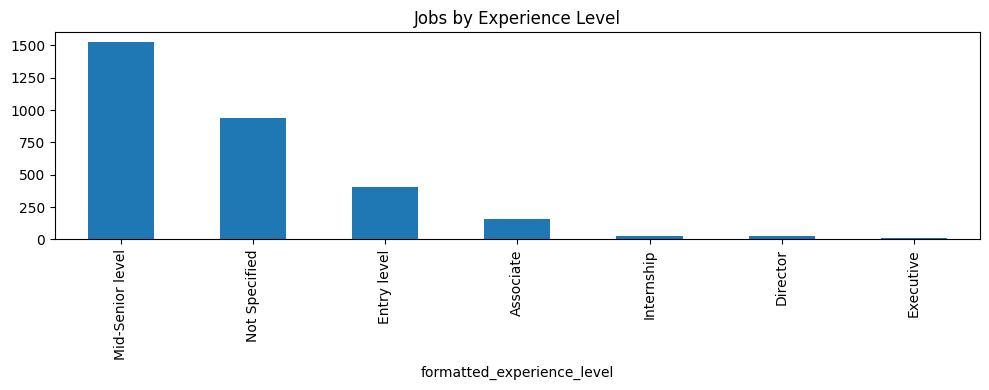

In [4]:
df["formatted_experience_level"].value_counts().plot(
    kind="bar", figsize=(10, 4), title="Jobs by Experience Level"
)
plt.tight_layout()
plt.show()

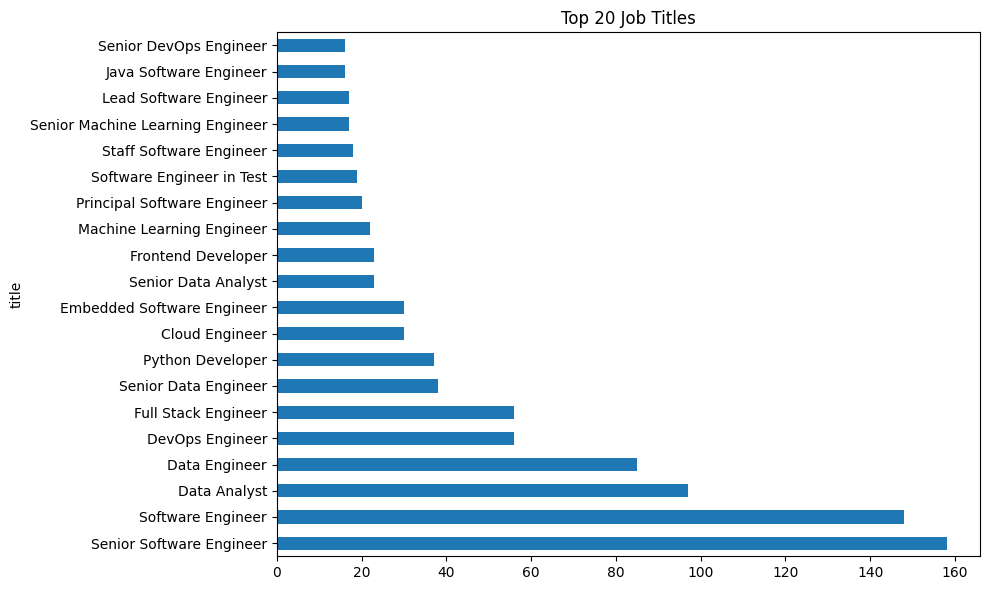

In [5]:
df["title"].value_counts().head(20).plot(
    kind="barh", figsize=(10, 6), title="Top 20 Job Titles"
)
plt.tight_layout()
plt.show()

count    3101.000000
mean      375.045147
std       156.750745
min         7.000000
25%       236.000000
50%       453.000000
75%       512.000000
max       512.000000
Name: combined_text_length, dtype: float64


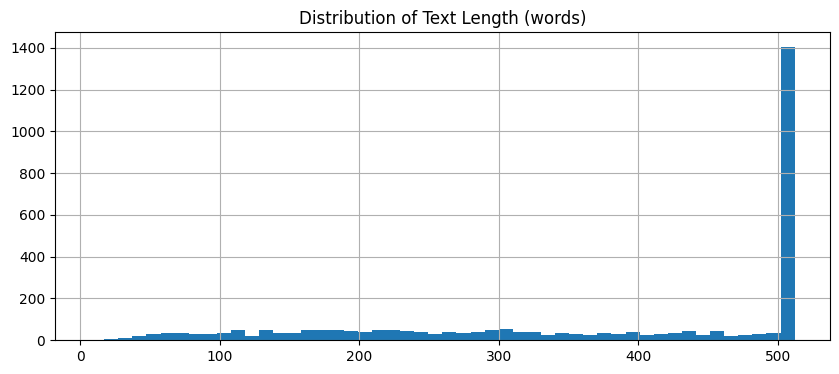

In [6]:
df["combined_text_length"] = df["combined_text"].str.split().str.len()
print(df["combined_text_length"].describe())
df["combined_text_length"].hist(bins=50, figsize=(10, 4))
plt.title("Distribution of Text Length (words)")
plt.show()

In [12]:

def create_combined_text(df):
    print("Creating combined text field...")

    def combine(row):
        title = str(row["title"]) if pd.notna(row["title"]) else ""
        skills = str(row["skills_desc"]) if pd.notna(row["skills_desc"]) else ""
        desc = str(row["description"]) if pd.notna(row["description"]) else ""
        # Title repeated twice to give it more weight
        combined = f"{title}. {title}. {skills}. {desc}"
        # Truncate to 512 words (safe for BERT)
        words = combined.split()[:512]
        return " ".join(words)

    df["combined_text"] = df.apply(combine, axis=1)
    return df

In [10]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
job_id                           0
title                            0
company_name                     0
description                      1
skills_desc                   3081
location                         0
formatted_experience_level       0
remote_allowed                   0
formatted_work_type              0
combined_text                    0
combined_text_length             0
dtype: int64


In [11]:
for i, row in df.sample(3, random_state=42).iterrows():
    print(f"\nTitle: {row['title']}")
    print(f"Company: {row['company_name']}")
    print(f"Experience: {row['formatted_experience_level']}")
    print(f"Text preview: {row['combined_text'][:300]}")
    print("-" * 60)


Title: Data Engineer General
Company: FastTek Global
Experience: Mid-Senior level
Text preview: Data Engineer General. Data Engineer General. . Data Factory Engineering and Operations (DFEO) is GDIA s organization for making data available to the enterprise at scale and delivering on Company s plan to become a data first company.Leveraging our long-term relationship with Google, Company s Data
------------------------------------------------------------

Title: Software Engineer - Infrastructure Platforms
Company: Cloudflare
Experience: Associate
Text preview: Software Engineer - Infrastructure Platforms. Software Engineer - Infrastructure Platforms. . About Us At Cloudflare, we have our eyes set on an ambitious goal to help build a better Internet. Today the company runs one of the world s largest networks that powers approximately 25 million Internet pr
------------------------------------------------------------

Title: Principal Embedded Software Engineer
Company: Softworld, a Kel